In [1]:
import pandas as pd

In [2]:
species = pd.read_csv("data/raw/train/_annotations.csv")

In [11]:
species

,filename,width,height,class,xmin,ymin,xmax,ymax
0,181140314_jpeg.rf.6369924b617349b8a82cda564da3...,500.0,375.0,Acanthophis antarcticus,160.0,134.0,289.0,282.0
1,90375393_jpg.rf.6b659c960421179c83dde6f81bf2a2...,375.0,500.0,Heterodon Platirhinos,64.0,148.0,325.0,275.0
2,96614639_jpeg.rf.7e53d271c17b4f7714c104d32281d...,500.0,375.0,Heterodon Platirhinos,20.0,154.0,360.0,340.0
3,199671252_jpeg.rf.a82334572b976f7eb72baeeb853f...,500.0,214.0,Heterodon Platirhinos,187.0,16.0,312.0,214.0
4,848617_jpg.rf.b6167489414b68fcfe2ccda38d24ac4a...,500.0,333.0,Ahaetulla prasina,127.0,0.0,375.0,333.0
...,...,...,...,...,...,...,...,...
12066,AUG31686445_jpeg.rf.4669cfa22ee64a17844b3cad97...,500.0,335.0,Acanthophis antarcticus,15.0,59.0,452.0,296.0
12067,223127820_jpg.rf.10e9024d3e7678529c4ea7715fcb2...,281.0,500.0,Thamnophis sirtalis,97.0,140.0,197.0,272.0
12068,224524660_jpeg.rf.4aecae9889cdc9eeef8b7e38f5ab...,500.0,500.0,Thamnophis sirtalis,95.0,89.0,365.0,500.0
12069,116497661_jpg.rf.69033f9ae5a7389f352ab3c9f6f9e...,500.0,224.0,Ptyas korros,1.0,94.0,500.0,213.0


In [6]:
species[species["class"].fillna("").str.lower() == "naja naja"]

,filename,width,height,class,xmin,ymin,xmax,ymax
21,141867635_jpg.rf.d2517e40dbbbc37f3aad6aa22ba7c...,500.0,500.0,Naja Naja,53.0,51.0,422.0,380.0
60,144061771_jpg.rf.cb67e0bf0a3ada9166018eb56c59a...,376.0,500.0,Naja Naja,130.0,200.0,337.0,382.0
92,AUG107330224_jpeg.rf.db6a6f6d5a0a5f25b25027bb2...,375.0,500.0,Naja Naja,53.0,62.0,352.0,446.0
150,AUG154534247_jpeg.rf.479cd4a6c6f24d1d1b342c0b1...,373.0,500.0,Naja Naja,0.0,0.0,296.0,349.0
154,AUG107330224_jpeg.rf.2f36972a3e9b315433096c91b...,375.0,500.0,Naja Naja,0.0,115.0,375.0,414.0
...,...,...,...,...,...,...,...,...
11889,56602063_jpg.rf.fd186f5cbc8f3bd5c759e2f160ca1a...,375.0,500.0,Naja Naja,118.0,119.0,274.0,325.0
11890,AUG34306497_jpeg.rf.ca7e2f4bf302ea8cc587608c45...,500.0,281.0,Naja Naja,111.0,4.0,415.0,222.0
11899,59100633_jpg.rf.d331da24d93134e8eaac985d234786...,500.0,281.0,Naja Naja,109.0,3.0,349.0,281.0
12037,93550860_jpeg.rf.f744ba242d84a2f451e7c46c5bf4d...,500.0,377.0,Naja Naja,126.0,187.0,341.0,353.0


In [7]:
import os
import shutil
import pandas as pd

# ===========================
# PATHS
# ===========================

SOURCE_FOLDER = r"data/raw/train"
CSV_FILE = os.path.join(SOURCE_FOLDER, "_annotations.csv")

DEST_FOLDER = r"Filtered_Train"

os.makedirs(DEST_FOLDER, exist_ok=True)

In [4]:
# ===========================
# TARGET SPECIES
# ===========================

TARGET_SPECIES = {
    "naja naja",
    "bungarus caeruleus",
    "daboia russelii",
    "ptyas korros",
    "ophiophagus hannah",
    "bungarus fasciatus",
    "chrysopelea ornata",
    "ptyas mucosa",
    "xenochrophis piscator",
    "amphiesma stolatum",
    "dendrelaphis pictus",
    "ahaetulla prasina",
    "psammodynastes pulverulentus",
    "trimeresurus albolabris",
    "trimeresurus purpureomaculatus"
}

In [8]:
# ===========================
# READ CSV
# ===========================

species = pd.read_csv(CSV_FILE)

# Normalize class names
species["class"] = (
    species["class"]
      .str.strip()
      .str.lower()
)

# Handle synonyms
species["class"] = species["class"].replace({
    "fowlea piscator": "xenochrophis piscator",
    "hebius stolatum": "amphiesma stolatum"
})

# Keep only target species
filtered = species[species["class"].isin(TARGET_SPECIES)]

# Remove duplicate filenames
filtered = filtered.drop_duplicates(subset="filename")

print(f"Images to copy: {len(filtered)}")


# import pandas as pd

# df = pd.read_csv("SnakeDetection.v9i.tensorflow/train/_annotations.csv")
# print(df.columns.tolist())   # shows the actual column names

Images to copy: 6110


In [ ]:
species

,filename,width,height,class,xmin,ymin,xmax,ymax
0,181140314_jpeg.rf.6369924b617349b8a82cda564da3...,500.0,375.0,acanthophis antarcticus,160.0,134.0,289.0,282.0
1,90375393_jpg.rf.6b659c960421179c83dde6f81bf2a2...,375.0,500.0,heterodon platirhinos,64.0,148.0,325.0,275.0
2,96614639_jpeg.rf.7e53d271c17b4f7714c104d32281d...,500.0,375.0,heterodon platirhinos,20.0,154.0,360.0,340.0
3,199671252_jpeg.rf.a82334572b976f7eb72baeeb853f...,500.0,214.0,heterodon platirhinos,187.0,16.0,312.0,214.0
4,848617_jpg.rf.b6167489414b68fcfe2ccda38d24ac4a...,500.0,333.0,ahaetulla prasina,127.0,0.0,375.0,333.0
...,...,...,...,...,...,...,...,...
12066,AUG31686445_jpeg.rf.4669cfa22ee64a17844b3cad97...,500.0,335.0,acanthophis antarcticus,15.0,59.0,452.0,296.0
12067,223127820_jpg.rf.10e9024d3e7678529c4ea7715fcb2...,281.0,500.0,thamnophis sirtalis,97.0,140.0,197.0,272.0
12068,224524660_jpeg.rf.4aecae9889cdc9eeef8b7e38f5ab...,500.0,500.0,thamnophis sirtalis,95.0,89.0,365.0,500.0
12069,116497661_jpg.rf.69033f9ae5a7389f352ab3c9f6f9e...,500.0,224.0,ptyas korros,1.0,94.0,500.0,213.0


In [ ]:
# ===========================
# COPY IMAGES
# ===========================

copied = 0
skipped = 0
missing = []

os.makedirs(DEST_FOLDER, exist_ok=True)

for filename in filtered["filename"].drop_duplicates().tolist():
    src = os.path.join(SOURCE_FOLDER, filename)
    dst = os.path.join(DEST_FOLDER, filename)

    if not os.path.exists(src):
        missing.append(filename)
        continue

    if os.path.exists(dst):
        skipped += 1
        continue

    shutil.copy2(src, dst)
    copied += 1

print(f"\nCopied : {copied}")
print(f"Skipped: {skipped}")
print(f"Missing: {len(missing)}")

if missing:
    print("\nMissing files:")
    for m in missing[:10]:
        print(m)

In [ ]:
species.info

<bound method DataFrame.info of                                                 filename  width  height  \
0      181140314_jpeg.rf.6369924b617349b8a82cda564da3...  500.0   375.0   
1      90375393_jpg.rf.6b659c960421179c83dde6f81bf2a2...  375.0   500.0   
2      96614639_jpeg.rf.7e53d271c17b4f7714c104d32281d...  500.0   375.0   
3      199671252_jpeg.rf.a82334572b976f7eb72baeeb853f...  500.0   214.0   
4      848617_jpg.rf.b6167489414b68fcfe2ccda38d24ac4a...  500.0   333.0   
...                                                  ...    ...     ...   
12066  AUG31686445_jpeg.rf.4669cfa22ee64a17844b3cad97...  500.0   335.0   
12067  223127820_jpg.rf.10e9024d3e7678529c4ea7715fcb2...  281.0   500.0   
12068  224524660_jpeg.rf.4aecae9889cdc9eeef8b7e38f5ab...  500.0   500.0   
12069  116497661_jpg.rf.69033f9ae5a7389f352ab3c9f6f9e...  500.0   224.0   
12070  113555626_jpg.rf.cf2c12cccaa71af4db7d659746cdb...  500.0   311.0   

                         class   xmin   ymin   xmax   ymax  
0     

In [ ]:
# ===========================
# SAVE FILTERED ANNOTATIONS
# ===========================

output_csv = os.path.join(DEST_FOLDER, "filtered_annotations.csv")

if os.path.exists(output_csv):
    print(f"{output_csv} already exists. Skipping save.")
else:
    filtered.to_csv(output_csv, index=False)
    print(f"Saved {output_csv}")

Filtered_Train\filtered_annotations.csv already exists. Skipping save.


In [ ]:
filtered_species = pd.read_csv(os.path.join(DEST_FOLDER, "filtered_annotations.csv"))

In [ ]:
filtered_species.sample(10)

,filename,width,height,class,xmin,ymin,xmax,ymax
4173,AUG168987290_jpeg.rf.097ca820c8508b0c38ae38579...,375.0,500.0,bungarus caeruleus,97.0,0.0,227.0,500.0
4887,79621934_jpeg.rf.8eecd586b3aba3ed2b7a06cc993ff...,500.0,417.0,naja naja,0.0,161.0,393.0,319.0
3387,12652405_jpg.rf.8c373cb9c68baa57ae2098ccb3faed...,375.0,500.0,ahaetulla prasina,90.0,135.0,335.0,368.0
5728,AUG138481199_jpeg.rf.5cd2f8d8a7208e925b0aed3bd...,417.0,500.0,bungarus caeruleus,135.0,135.0,347.0,373.0
899,67722408_jpeg.rf.6dd4bba1bf00c6c598e05ff3884c4...,333.0,500.0,chrysopelea ornata,0.0,200.0,333.0,288.0
3867,99441708_jpeg.rf.d10219f8b20cb9464a298e404ed39...,500.0,333.0,amphiesma stolatum,50.0,37.0,500.0,255.0
4313,AUG21918748943_jpg.rf.08694bcf7bf482d79c254559...,375.0,500.0,daboia russelii,121.0,127.0,375.0,365.0
3671,139695889_jpg.rf.18be95e5cfa1c5b73b5f2f588de78...,375.0,500.0,ptyas korros,98.0,0.0,362.0,420.0
2837,199592663_jpg.rf.fb747251a94d39f92f3100a63cc62...,448.0,361.0,xenochrophis piscator,96.0,0.0,448.0,307.0
3389,83517146_jpeg.rf.b698dd65e92a0590f01f756c92be5...,500.0,281.0,ptyas mucosa,0.0,0.0,349.0,281.0


In [ ]:
import os
import shutil
import pandas as pd

SOURCE_FOLDER = r"SnakeDetection.v9i.tensorflow/train"
DEST_FOLDER = r"Filtered_Train"

os.makedirs(DEST_FOLDER, exist_ok=True)

copied = 0
skipped = 0
missing = []

for filename in filtered_species["filename"].drop_duplicates().tolist():
    src = os.path.join(SOURCE_FOLDER, filename)
    dst = os.path.join(DEST_FOLDER, filename)

    if not os.path.exists(src):
        missing.append(filename)
        continue

    if os.path.exists(dst):
        skipped += 1
        continue

    shutil.copy2(src, dst)
    copied += 1

print(f"Copied {copied} images.")
print(f"Skipped {skipped} images (already existed).")
print(f"Missing {len(missing)} files.")

if missing:
    print("\nMissing files:")
    for m in missing[:10]:
        print(m)

Copied 0 images.
Skipped 6110 images (already existed).
Missing 0 files.


In [ ]:
# One row per image
image_classes = (
    filtered_species[["filename", "class"]]
    .drop_duplicates()
)


# Count images per class
class_distribution = (
    image_classes["class"]
    .value_counts()
    .sort_values(ascending=False)
)

print("=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)
print(class_distribution)

print("\n")

print(f"Total Images  : {len(image_classes)}")
print(f"Total Classes : {image_classes['class'].nunique()}")

CLASS DISTRIBUTION
class
naja naja                         425
psammodynastes pulverulentus      420
amphiesma stolatum                420
xenochrophis piscator             417
ahaetulla prasina                 414
trimeresurus albolabris           408
chrysopelea ornata                408
dendrelaphis pictus               408
ptyas mucosa                      408
bungarus fasciatus                408
ptyas korros                      405
ophiophagus hannah                402
bungarus caeruleus                399
daboia russelii                   396
trimeresurus purpureomaculatus    372
Name: count, dtype: int64


Total Images  : 6110
Total Classes : 15


In [ ]:
distribution_df = class_distribution.reset_index()
distribution_df.columns = ["Species", "Images"]

distribution_df["Percentage"] = (
    distribution_df["Images"] / distribution_df["Images"].sum() * 100
).round(2)

distribution_df

,Species,Images,Percentage
0,naja naja,425,6.96
1,psammodynastes pulverulentus,420,6.87
2,amphiesma stolatum,420,6.87
3,xenochrophis piscator,417,6.82
4,ahaetulla prasina,414,6.78
5,trimeresurus albolabris,408,6.68
6,chrysopelea ornata,408,6.68
7,dendrelaphis pictus,408,6.68
8,ptyas mucosa,408,6.68
9,bungarus fasciatus,408,6.68


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

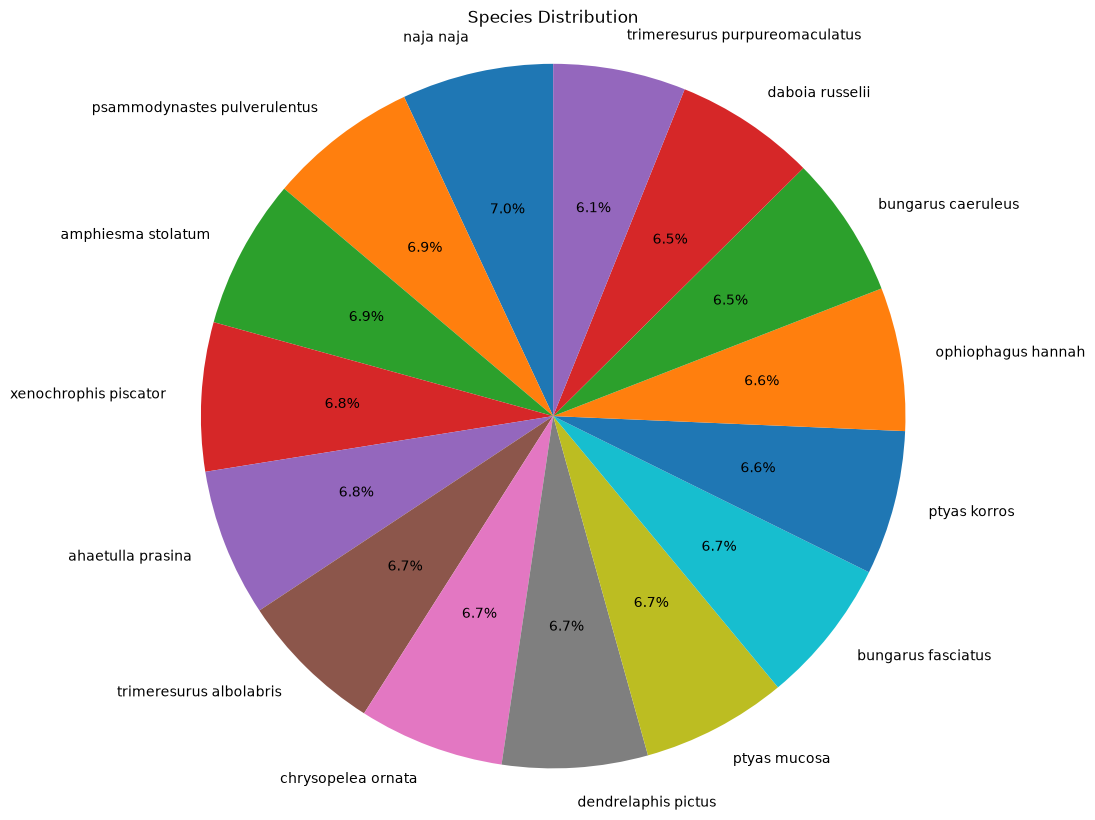

In [ ]:
plt.figure(figsize=(10, 10))
plt.pie(
    distribution_df["Images"],
    labels=distribution_df["Species"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Species Distribution")
plt.axis("equal")
plt.show()

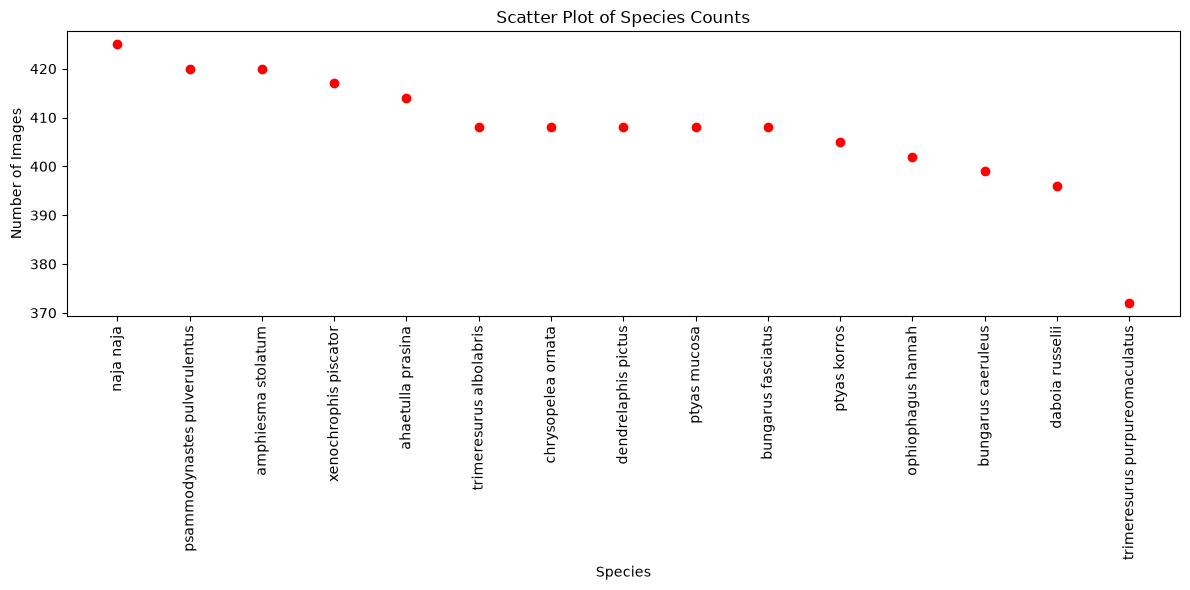

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(distribution_df["Species"], distribution_df["Images"], color="red")
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.xlabel("Species")
plt.title("Scatter Plot of Species Counts")
plt.tight_layout()
plt.show()

In [ ]:

max_images = class_distribution.max()
min_images = class_distribution.min()

imbalance_ratio = round(max_images / min_images, 2)

print(f"Largest Class   : {max_images}")
print(f"Smallest Class  : {min_images}")
print(f"Imbalance Ratio : {imbalance_ratio}")

Largest Class   : 425
Smallest Class  : 372
Imbalance Ratio : 1.14


In [ ]:
from pathlib import Path
from collections import Counter
from PIL import Image

In [ ]:
IMAGE_FOLDER = r"f:\Samir\Projects\SnakeSense\Filtered_Train"
ALLOWED_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def get_image_files(folder, extensions=None):
    folder = Path(folder)

    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")

    allowed = {ext.lower() for ext in (extensions or [])}
    image_files = []

    for file_path in folder.rglob("*"):
        if file_path.is_file():
            ext = file_path.suffix.lower()
            if allowed and ext not in allowed:
                continue
            image_files.append(str(file_path))

    return image_files

In [ ]:
def collect_image_stats(image_files):
    image_stats = []
    corrupted_images = []

    for filepath in image_files:
        filename = os.path.basename(filepath)

        try:
            with Image.open(filepath) as img:
                width, height = img.size

                image_stats.append({
                    "Filename": filename,
                    "Path": filepath,
                    "Width": width,
                    "Height": height,
                    "Aspect_Ratio": round(width / height, 2),
                    "Mode": img.mode,
                    "Format": img.format,
                    "File_Size_KB": round(os.path.getsize(filepath) / 1024, 2),
                })

        except Exception as e:
            corrupted_images.append({
                "Filename": filename,
                "Path": filepath,
                "Error": str(e),
            })

    stats_df = pd.DataFrame(image_stats)
    corrupted_df = pd.DataFrame(corrupted_images)

    return stats_df, corrupted_df

In [ ]:
# 1) Create image list
image_files = get_image_files(IMAGE_FOLDER, ALLOWED_EXTENSIONS)

# 2) Create DataFrames
stats_df, corrupted_df = collect_image_stats(image_files)

print(f"Images scanned : {len(stats_df)}")
print(f"Corrupted      : {len(corrupted_df)}")
print("\nExtension counts:")
print(Counter(Path(p).suffix.lower() for p in image_files))

Images scanned : 6109
Corrupted      : 1

Extension counts:
Counter({'.jpg': 6110})


In [ ]:
# Check result
print(stats_df["Mode"].value_counts())
print(stats_df.head())

Mode
RGB    6109
Name: count, dtype: int64
                                            Filename  \
0  10019777_jpg.rf.3fa3e9e51685dbbe4ac0e468b1e18f...   
1  10019777_jpg.rf.5083e029e03108620060ed89b3d28a...   
2  10019777_jpg.rf.eac431f9b2eeb2fbfe0f0f2271336e...   
3  100346464_jpeg.rf.4614a9c08bc56c3908022f26e4b1...   
4  100346464_jpeg.rf.646aa5d6668eea795644469e9ec1...   

                                                Path  Width  Height  \
0  f:\Samir\Projects\SnakeSense\Filtered_Train\10...    500     333   
1  f:\Samir\Projects\SnakeSense\Filtered_Train\10...    500     333   
2  f:\Samir\Projects\SnakeSense\Filtered_Train\10...    500     333   
3  f:\Samir\Projects\SnakeSense\Filtered_Train\10...    387     353   
4  f:\Samir\Projects\SnakeSense\Filtered_Train\10...    387     353   

   Aspect_Ratio Mode Format  File_Size_KB  
0           1.5  RGB   JPEG         27.67  
1           1.5  RGB   JPEG         27.61  
2           1.5  RGB   JPEG         44.68  
3           1.1  

In [ ]:
stats_df.head()

,Filename,Path,Width,Height,Aspect_Ratio,Mode,Format,File_Size_KB
0,10019777_jpg.rf.3fa3e9e51685dbbe4ac0e468b1e18f...,f:\Samir\Projects\SnakeSense\Filtered_Train\10...,500,333,1.5,RGB,JPEG,27.67
1,10019777_jpg.rf.5083e029e03108620060ed89b3d28a...,f:\Samir\Projects\SnakeSense\Filtered_Train\10...,500,333,1.5,RGB,JPEG,27.61
2,10019777_jpg.rf.eac431f9b2eeb2fbfe0f0f2271336e...,f:\Samir\Projects\SnakeSense\Filtered_Train\10...,500,333,1.5,RGB,JPEG,44.68
3,100346464_jpeg.rf.4614a9c08bc56c3908022f26e4b1...,f:\Samir\Projects\SnakeSense\Filtered_Train\10...,387,353,1.1,RGB,JPEG,27.86
4,100346464_jpeg.rf.646aa5d6668eea795644469e9ec1...,f:\Samir\Projects\SnakeSense\Filtered_Train\10...,387,353,1.1,RGB,JPEG,28.06


In [ ]:
corrupted_df.head()

,Filename,Path,Error
0,41909982_jpg.rf.47525d16a431a0c56efcfeabc504d2...,f:\Samir\Projects\SnakeSense\Filtered_Train\41...,cannot identify image file 'f:\\Samir\\Project...


In [ ]:
print("="*50)
print("IMAGE DATASET SUMMARY")
print("="*50)

print(f"Total Images : {len(stats_df)}")

print("\nResolution")

print(f"Average Width  : {stats_df['Width'].mean():.0f}")
print(f"Average Height : {stats_df['Height'].mean():.0f}")

print(f"Minimum Width  : {stats_df['Width'].min()}")
print(f"Maximum Width  : {stats_df['Width'].max()}")

print(f"Minimum Height : {stats_df['Height'].min()}")
print(f"Maximum Height : {stats_df['Height'].max()}")

print("\nAverage File Size")

print(f"{stats_df['File_Size_KB'].mean():.2f} KB")

IMAGE DATASET SUMMARY
Total Images : 6109

Resolution
Average Width  : 455
Average Height : 398
Minimum Width  : 164
Maximum Width  : 500
Minimum Height : 125
Maximum Height : 500

Average File Size
34.43 KB


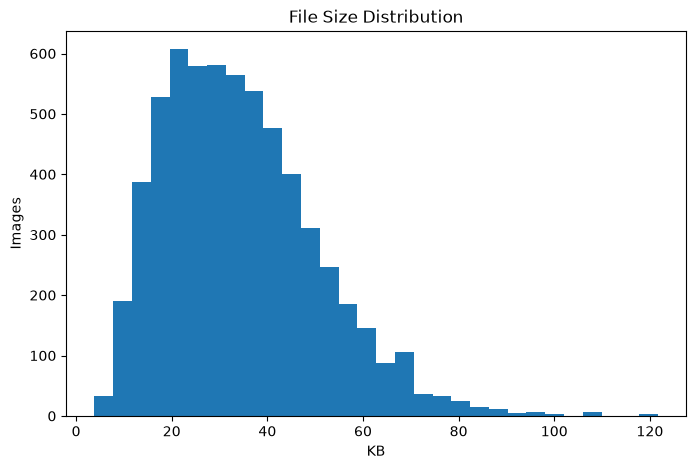

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(stats_df["File_Size_KB"], bins=30)
plt.title("File Size Distribution")
plt.xlabel("KB")
plt.ylabel("Images")
plt.show()

In [ ]:
IMAGE_FOLDER = r"f:\Samir\Projects\SnakeSense\Filtered_Train"
reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)

In [ ]:
# Assumes these already exist:
# - stats_df
# - corrupted_df
# - filtered_species

# Start with successful images
image_stats_df = stats_df.copy()

# Standardize column names
image_stats_df = image_stats_df.rename(columns={
    "Filename": "filename",
    "Path": "path",
    "Width": "width",
    "Height": "height",
    "Aspect_Ratio": "aspect_ratio",
    "Mode": "mode",
    "Format": "format",
    "File_Size_KB": "file_size_kb",
})

# Add useful columns
image_stats_df["extension"] = image_stats_df["path"].apply(lambda p: Path(p).suffix.lower())
image_stats_df["file_size_bytes"] = image_stats_df["path"].apply(lambda p: os.path.getsize(p))
image_stats_df["is_corrupted"] = False
image_stats_df["error"] = None
image_stats_df["class"] = None

# Add class labels from filtered_annotations.csv
if "class" in filtered_species.columns:
    class_map = filtered_species[["filename", "class"]].drop_duplicates()
    class_map["filename"] = class_map["filename"].astype(str).apply(lambda x: Path(x).name)
    image_stats_df = image_stats_df.merge(class_map, on="filename", how="left")

In [ ]:
if not corrupted_df.empty:
    corrupted_rows = pd.DataFrame({
        "filename": corrupted_df["Filename"],
        "path": corrupted_df["Path"],
        "width": [None] * len(corrupted_df),
        "height": [None] * len(corrupted_df),
        "aspect_ratio": [None] * len(corrupted_df),
        "mode": [None] * len(corrupted_df),
        "format": [None] * len(corrupted_df),
        "file_size_kb": [None] * len(corrupted_df),
        "extension": corrupted_df["Path"].apply(lambda p: Path(p).suffix.lower()),
        "file_size_bytes": [None] * len(corrupted_df),
        "is_corrupted": [True] * len(corrupted_df),
        "error": corrupted_df["Error"],
        "class": [None] * len(corrupted_df),
    })

    if "class" in filtered_species.columns:
        class_map = filtered_species[["filename", "class"]].drop_duplicates()
        class_map["filename"] = class_map["filename"].astype(str).apply(lambda x: Path(x).name)
        corrupted_rows = corrupted_rows.merge(class_map, on="filename", how="left")

    image_stats_df = pd.concat([image_stats_df, corrupted_rows], ignore_index=True)

In [ ]:
# Assumes these already exist:
# - stats_df
# - corrupted_df
# - filtered_species

# Start with successful images
image_stats_df = stats_df.copy()

# Standardize column names
image_stats_df = image_stats_df.rename(columns={
    "Filename": "filename",
    "Path": "path",
    "Width": "width",
    "Height": "height",
    "Aspect_Ratio": "aspect_ratio",
    "Mode": "mode",
    "Format": "format",
    "File_Size_KB": "file_size_kb",
})

# Add useful columns
image_stats_df["extension"] = image_stats_df["path"].apply(lambda p: Path(p).suffix.lower())
image_stats_df["file_size_bytes"] = image_stats_df["path"].apply(lambda p: os.path.getsize(p))
image_stats_df["is_corrupted"] = False
image_stats_df["error"] = None

# Create class column safely
image_stats_df["class"] = None

# Add class labels from filtered_annotations.csv
if "class" in filtered_species.columns:
    class_map = filtered_species[["filename", "class"]].drop_duplicates()
    class_map["filename"] = class_map["filename"].astype(str).apply(lambda x: Path(x).name)

    # Rename incoming class column to avoid conflict
    class_map = class_map.rename(columns={"class": "class_from_csv"})

    image_stats_df = image_stats_df.merge(
        class_map,
        on="filename",
        how="left"
    )

    # Fill the existing class column from the merged one
    image_stats_df["class"] = image_stats_df["class_from_csv"].fillna(image_stats_df["class"])
    image_stats_df = image_stats_df.drop(columns=["class_from_csv"])

In [ ]:
# Class summary
if "class" not in image_stats_df.columns:
    raise KeyError("image_stats_df still does not contain a 'class' column")

class_summary_df = (
    image_stats_df.dropna(subset=["class"])
    .groupby("class", dropna=False)
    .agg(
        class_images=("filename", "count"),
        class_unique_files=("filename", "nunique"),
        class_corrupted_images=("is_corrupted", "sum")
    )
    .reset_index()
)

class_summary_df["class_percentage"] = (
    class_summary_df["class_images"] / class_summary_df["class_images"].sum() * 100
).round(2)

# Dataset-level summary
dataset_total_images = len(image_stats_df)
dataset_total_classes = image_stats_df["class"].nunique(dropna=False)

largest_class_images = class_summary_df["class_images"].max() if not class_summary_df.empty else None
smallest_class_images = class_summary_df["class_images"].min() if not class_summary_df.empty else None

if smallest_class_images not in [None, 0]:
    imbalance_ratio = round(largest_class_images / smallest_class_images, 2)
else:
    imbalance_ratio = None

# Add summary columns to every row
image_stats_df["dataset_total_images"] = dataset_total_images
image_stats_df["dataset_total_classes"] = dataset_total_classes
image_stats_df["largest_class_images"] = largest_class_images
image_stats_df["smallest_class_images"] = smallest_class_images
image_stats_df["imbalance_ratio"] = imbalance_ratio
image_stats_df["generated_at"] = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

In [ ]:
output_csv = reports_dir / "dataset_report.csv"
image_stats_df.to_csv(output_csv, index=False)

print(f"Saved: {output_csv}")
image_stats_df.head()

Saved: reports\dataset_report.csv


,filename,path,width,height,aspect_ratio,mode,format,file_size_kb,extension,file_size_bytes,is_corrupted,error,class,dataset_total_images,dataset_total_classes,largest_class_images,smallest_class_images,imbalance_ratio,generated_at
0,10019777_jpg.rf.3fa3e9e51685dbbe4ac0e468b1e18f...,f:\Samir\Projects\SnakeSense\Filtered_Train\10...,500,333,1.5,RGB,JPEG,27.67,.jpg,28333,False,None,bungarus fasciatus,6109,15,425,372,1.14,2026-07-17 14:55:12
1,10019777_jpg.rf.5083e029e03108620060ed89b3d28a...,f:\Samir\Projects\SnakeSense\Filtered_Train\10...,500,333,1.5,RGB,JPEG,27.61,.jpg,28268,False,None,bungarus fasciatus,6109,15,425,372,1.14,2026-07-17 14:55:12
2,10019777_jpg.rf.eac431f9b2eeb2fbfe0f0f2271336e...,f:\Samir\Projects\SnakeSense\Filtered_Train\10...,500,333,1.5,RGB,JPEG,44.68,.jpg,45755,False,None,bungarus fasciatus,6109,15,425,372,1.14,2026-07-17 14:55:12
3,100346464_jpeg.rf.4614a9c08bc56c3908022f26e4b1...,f:\Samir\Projects\SnakeSense\Filtered_Train\10...,387,353,1.1,RGB,JPEG,27.86,.jpg,28525,False,None,ptyas mucosa,6109,15,425,372,1.14,2026-07-17 14:55:12
4,100346464_jpeg.rf.646aa5d6668eea795644469e9ec1...,f:\Samir\Projects\SnakeSense\Filtered_Train\10...,387,353,1.1,RGB,JPEG,28.06,.jpg,28735,False,None,ptyas mucosa,6109,15,425,372,1.14,2026-07-17 14:55:12


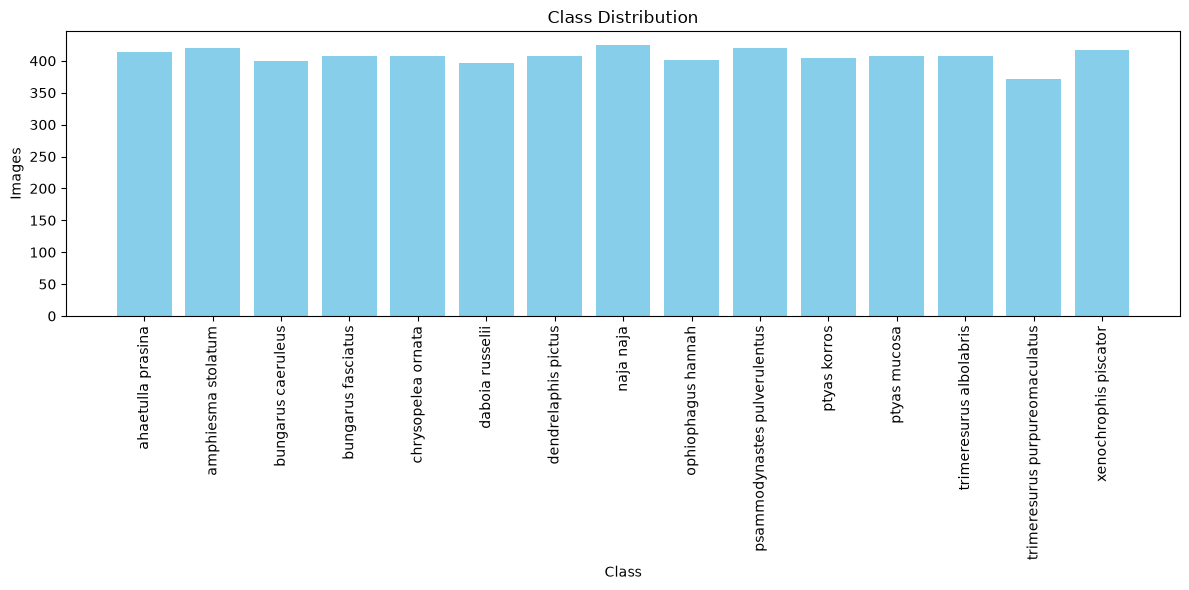

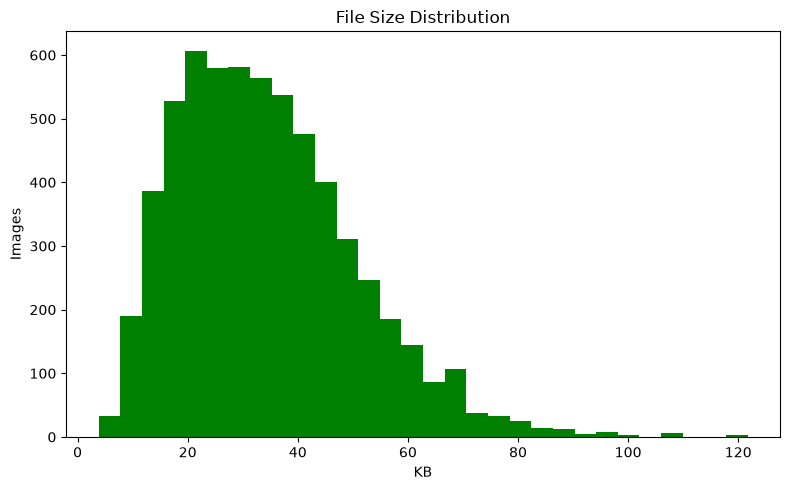

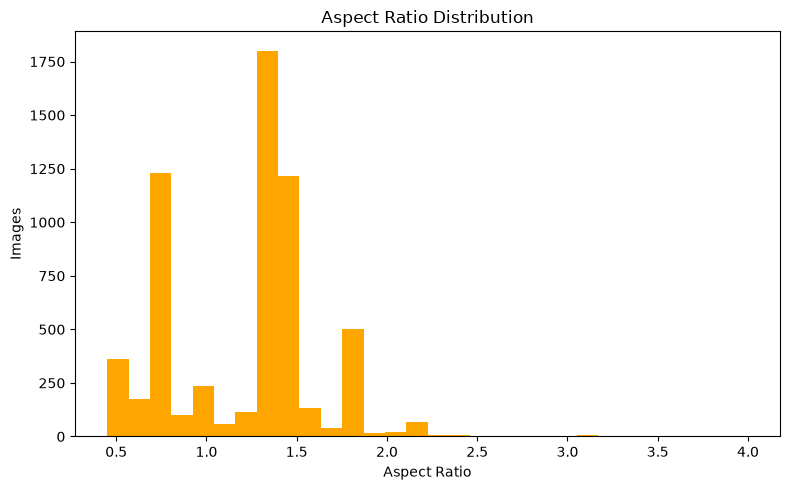

In [ ]:
# 1) Class distribution chart
plt.figure(figsize=(12, 6))
plt.bar(class_summary_df["class"], class_summary_df["class_images"], color="skyblue")
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Images")
plt.tight_layout()
plt.savefig(reports_dir / "class_distribution.png", dpi=200)
plt.show()

# 2) File size chart
plt.figure(figsize=(8, 5))
plt.hist(image_stats_df["file_size_kb"].dropna(), bins=30, color="green")
plt.title("File Size Distribution")
plt.xlabel("KB")
plt.ylabel("Images")
plt.tight_layout()
plt.savefig(reports_dir / "file_size_distribution.png", dpi=200)
plt.show()

# 3) Aspect ratio chart
plt.figure(figsize=(8, 5))
plt.hist(image_stats_df["aspect_ratio"].dropna(), bins=30, color="orange")
plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Images")
plt.tight_layout()
plt.savefig(reports_dir / "aspect_ratio_distribution.png", dpi=200)
plt.show()